<a href="https://colab.research.google.com/github/MuhamadRizki10R2/NLP-Models-ChatbotQnA/blob/main/Rizki_NLP_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chatbot.Stella - NLP Model QnA pake Persamaan Kosinus**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berhasil memuat 48 baris data.


,question,answer
0,Hallo Stella AI,"Hii juga, gimana nih apakah ada yang ingin di ..."
1,Apa itu SMK Telkom Lampung?,SMK Telkom Lampung adalah sekolah menengah kej...
2,Dimana alamat SMK Telkom Lampung?,"Alamat lengkap: J3GJ+52W, Jl. Raya Gadingrejo,..."
3,Bagaimana cara mendaftar di SMK Telkom Lampung?,Umumnya pendaftaran dilakukan dengan mengisi f...
4,Kapan pendaftaran dibuka?,Pendaftaran Seleksi Penerimaan Murid Baru (SPM...


DataFrame columns: Index(['question', 'answer'], dtype='object')
Apakah ada data kosong?
question    0
answer      0
dtype: int64

Contoh jawaban pertama: Hii juga, gimana nih apakah ada yang ingin di tanyakan seputar SMK Telkom Lampung?


,question,answer
0,Hallo Stella AI,"Hii juga, gimana nih apakah ada yang ingin di ..."
1,Apa itu SMK Telkom Lampung?,SMK Telkom Lampung adalah sekolah menengah kej...
2,Dimana alamat SMK Telkom Lampung?,"Alamat lengkap: J3GJ+52W, Jl. Raya Gadingrejo,..."
3,Bagaimana cara mendaftar di SMK Telkom Lampung?,Umumnya pendaftaran dilakukan dengan mengisi f...
4,Kapan pendaftaran dibuka?,Pendaftaran Seleksi Penerimaan Murid Baru (SPM...


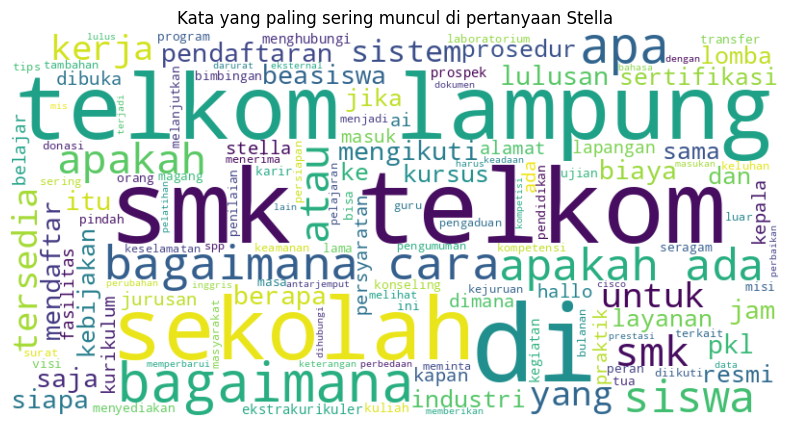

/tmp/ipython-input-3166606887.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='word', data=tfidf_df, palette='viridis')


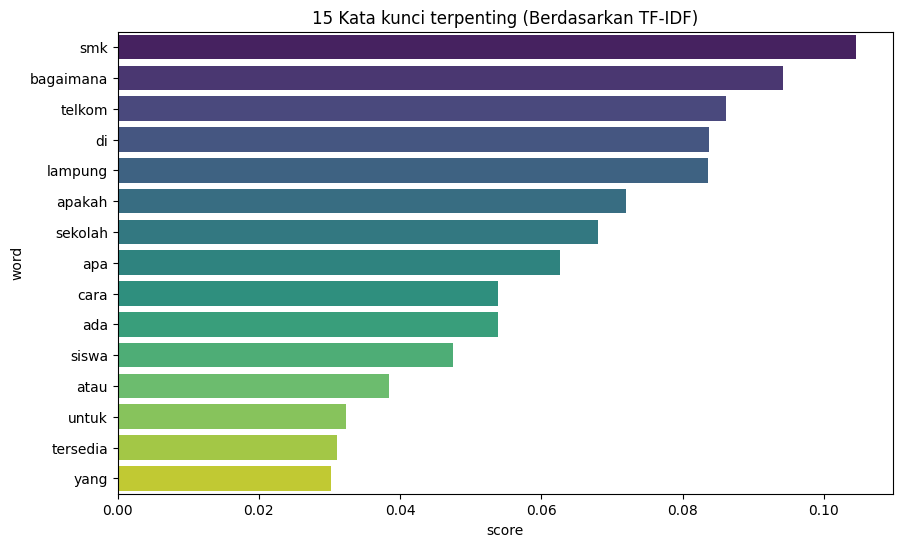

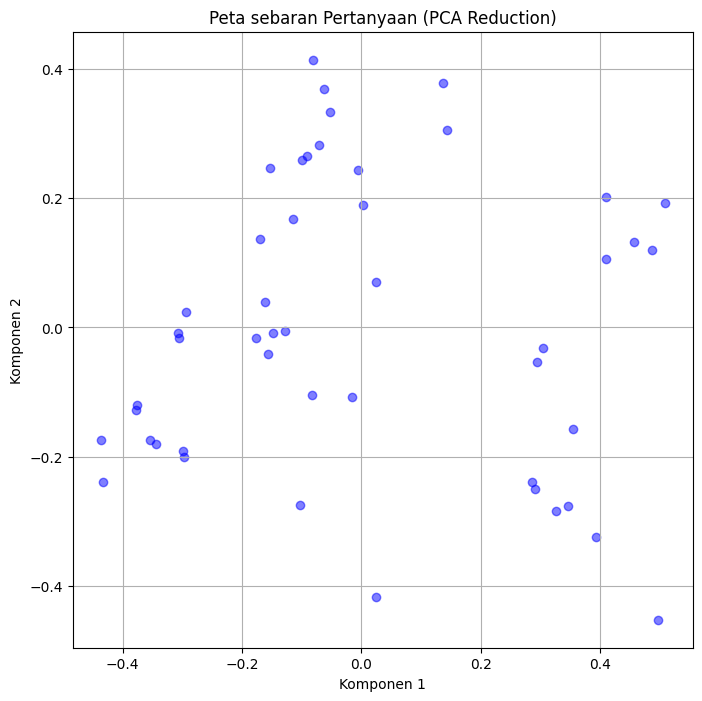

Hai, saya Chatbot.Stella. Tanyakan apa saja seputar SMK Telkom Lampung! ketik 'exit' untuk keluar.

Anda: siapa kepala sekolah smk telkom lampung
Chatbot.stella (1.00): Kepala Sekolah SMK Telkom Lampung adalah Dedi Eko Cahyono, S. Kom, G.r

Anda: kapan ppdb smk telkom lampung dibuka
Chatbot.stella (0.72): Pendaftaran Seleksi Penerimaan Murid Baru (SPMB) SMK Telkom Lampung untuk tahun ajaran 2026/2027 Gelombang 1 sudah dibuka sejak Oktober 2025.



In [ ]:
# Import Library nya
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
from sklearn.decomposition import PCA

# Dataset
from google.colab import drive
drive.mount('/content/drive')

df = None # Initialize df to None to prevent NameError if CSV reading fails
try:
    # Menggunakan sep=None dan engine='python' agar Pandas mendeteksi pemisah otomatis
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/Data NLP mini Project/Salinan_dataset_Qa.csv',
                     sep=None,
                     engine='python',
                     on_bad_lines='skip')

    # Karena kita tidak pakai names=['question', 'answer'] di read_csv agar tidak bentrok,
    # kita namai kolomnya setelah berhasil terbaca
    df.columns = ['question', 'answer']

    # Bersihkan data
    df = df.dropna(subset=['question', 'answer'])
    df['answer'] = df['answer'].astype(str)
    df['question'] = df['question'].astype(str)

    print(f"Berhasil memuat {len(df)} baris data.")
    display(df.head())

except Exception as e:
    print(f"Terjadi kesalahan: {e}")

if df is not None:
    # Menampilkan data Tabel
    # --- PROSES DATA ---
    print("DataFrame columns:", df.columns)
    print("Apakah ada data kosong?")
    print(df.isnull().sum())
    print("\nContoh jawaban pertama:", df['answer'].iloc[0])
    display(df.head())

    # Preprocessing Data
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        text = text.strip()
        return text

    df['clean_question'] = df['question'].apply(clean_text)

    # TF-IDF Vectorizer
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(df['clean_question'])

    # Visualisasi data

    # visualisasi pake Word Cloud
    def plot_wordcloud(data):
      all_words = ' '.join(data['clean_question'])
      wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

      plt.figure(figsize=(10, 5))
      plt.imshow(wordcloud, interpolation='bilinear')
      plt.axis('off')
      plt.title('Kata yang paling sering muncul di pertanyaan Stella')
      plt.show()

    # Visualisasi Top pake TF-IDF Terms
    def plot_tfidf_bar(vectorizer, tfidf_matrix):
      importance = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
      tfidf_df = pd.DataFrame({'word': vectorizer.get_feature_names_out(), 'score': importance})
      tfidf_df = tfidf_df.sort_values(by='score', ascending=False).head(15)

      plt.figure(figsize=(10, 6))
      sns.barplot(x='score', y='word', data=tfidf_df, palette='viridis')
      plt.title('15 Kata kunci terpenting (Berdasarkan TF-IDF)')
      plt.show()

    # Visualisasi pake PCA
    def plot_pca_scatter(tfidf_matrix):
      pca = PCA(n_components=2)
      reduced_vecs = pca.fit_transform(tfidf_matrix.toarray())

      plt.figure(figsize=(8, 8))
      plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], alpha=0.5, c='blue')
      plt.title('Peta sebaran Pertanyaan (PCA Reduction)')
      plt.xlabel('Komponen 1')
      plt.ylabel('Komponen 2')
      plt.grid(True)
      plt.show()

     # buat manggil fungsi visualisasi setelah vectorizer.fit_transform
    plot_wordcloud(df)
    plot_tfidf_bar(vectorizer, tfidf_matrix)
    plot_pca_scatter(tfidf_matrix)

    # function untuk mendapatkan jawaban
    def chatbot_stella(user_input, threshold=0.3):
        user_input_clean = clean_text(user_input)
        user_vec = vectorizer.transform([user_input_clean])

        # Hitung Cosine Similarity
        similarity = cosine_similarity(user_vec, tfidf_matrix)

        # Ambil skor tertinggi
        idx = np.argmax(similarity)
        score = similarity[0][idx]

        if score >= threshold:
            response = df.iloc[idx]['answer']
        else:
            response = "Maaf, Chatbot.stella belum memahami pertanyaan itu."

        return response, score

    # Chat Loop (bisa diganti antarmuka Flask/Gradio nanti)
    print("Hai, saya Chatbot.Stella. Tanyakan apa saja seputar SMK Telkom Lampung! ketik 'exit' untuk keluar.\n")

    while True:
        user_q = input("Anda: ")
        if user_q.lower() in ['exit', 'quit', 'keluar']:
            print("Chatbot.Stella: Terima kasih! Sampai jumpa.")
            break

        answer, sim_score = chatbot_stella(user_q)
        print(f"Chatbot.stella ({sim_score:.2f}): {answer}\n")
else:
    print("DataFrame 'df' was not loaded due to errors. Cannot proceed with data processing and chatbot functions.")